# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt  # importar librerías

In [3]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [4]:
print("Plans:")
plans.head() # mostrar las primeras 5 filas de plans

Plans:


,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [5]:
print("Users:")
users.head()# mostrar las primeras 5 filas de users

Users:


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [6]:
print("Usage:")
usage.head()# mostrar las primeras 5 filas de usage

Usage:


,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [7]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [8]:
plans.info()# inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [9]:
users.info()# inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [10]:
usage.info()# inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [11]:
print("Nulos en users")
print(users.isna().sum())
print("Proporción de nulos en users (%)")
print((users.isna().mean()* 100).round(2))

Nulos en users
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
Proporción de nulos en users (%)
user_id        0.00
first_name     0.00
last_name      0.00
age            0.00
city          11.72
reg_date       0.00
plan           0.00
churn_date    88.35
dtype: float64


In [12]:
print("Nulos en usage")
print(usage.isna().sum()) 
print("Proporción de nulos en usage (%)")
print((usage.isna().mean() * 100).round(2))# cantidad de nulos para usage

Nulos en usage
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
Proporción de nulos en usage (%)
id           0.00
user_id      0.00
type         0.00
date         0.12
duration    55.19
length      44.74
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
    Para Users las columnas que tienen valores nulos son:
  City tiene 459 datos nulos que corresponden al 12% del total de valores 
  Churn_date 3454 datos nulos que corresponden al 88% del total de valores 

  Para Usage las columnas que tienen valores nulos son:
date tiene 50 valores nulos que corresponden al 12% del total de valores 
duration tiene 22,076 datos nulos que corresponden al 55.19% del total de valores
length tiene 17,896 datos nulos que corresponden al 44.74 % del total de valores 
  
- Indica qué harías: ¿imputar, eliminar, ignorar?
  Para el data set de Users
en City investigaria un poco mas antes de imputar debido a que el valor de los nulos corresponden al 12%
en Churn date no se recomendaria imputar ni eliminar ademas de verificar que estos valores nulos sean de los usuarios que siguen activos en sus planes.


Para el data set de Usage 
en date se puede eliminar los registros por el bajo porcentaje de valores nulos 
En duration antes de eliminar o imputar se debe tener un pooco mas de investigacion para ver si los nulos estas asociados a ciertos tipos de uso 
en lenght Se recomienda analizar su relación con la columna type, ya que podrían ser valores faltantes esperados dependiendo del tipo de actividad registrada.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [13]:
users.describe() # explorar columnas numéricas de users

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` en esta columna no se observan sentinels, sin embargo se observa que la desviacion estandar esta muy alejada de la media y el resto de los valores ... Haz doble clic en este bloque y escribe qué ves.
- La columna `age` tiene un sentinel de -999 

In [14]:
usage.describe()# explorar columnas numéricas de usage

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`
  La columna duration tiene valores entre 0 y 120 minutos. No se observan valores negativos; sin embargo, existen registros con duración igual a 0, los cuales deben investigarse para determinar si representan llamadas no completadas o posibles errores de captura.

 La columna length tiene valores entre 0 y 1490. No presenta valores negativos, pero también contiene registros con valor 0 que podrían representar actividades sin consumo o posibles inconsistencias.

 No se identifican sentinels evidentes en las variables numéricas de usage. Sin embargo, los valores mínimos iguales a 0 en duration y length deben revisarse para confirmar si son válidos dentro del contexto del negocio.

In [15]:

# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for col in columnas_user:
    print(f'\n{col}')
    print(users[col].unique())


city
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

plan
['Basico' 'Premium']


- La columna `city` tiene un sentinel  de '?' y tambien valores nulos
- La columna `plan` solo tiene e columnas categoricas

In [16]:

# explorar columna categórica de usage
usage['type'].unique() # completa el código


array(['call', 'text'], dtype=object)

- La columna `type` La columna type contiene únicamente dos categorías: 'call' y 'text'. No se identifican valores inválidos, errores de escritura ni categorías inesperadas, por lo que no parece requerir limpieza adiciona


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 


**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
   En la columna age del dataset users se identificó el valor -999, el cual representa una edad imposible y probablemente fue utilizado como sentinel para indicar un dato faltante o desconocido.

 En la columna city se identificó el valor '?', que no corresponde a una ciudad válida y probablemente representa información faltante o no registrada. Además, también existen valores nulos (NaN).
 
- ¿Qué acción tomarías?  
 Reemplazar los valores -999 en age y '?' en city por NaN para tratarlos como valores faltantes. Posteriormente se podrá evaluar una estrategia de imputación o mantenerlos como nulos según las necesidades del análisis.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [17]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce') # completa el código

In [18]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce') # completa el código

In [19]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts().sort_index())


2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date` se detectaron 40 registros para el año 2026, esto representa una fecha fuera de rango, pues en las instrucciones menciona que solo hay datos hasta el año 2024

In [20]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts().sort_index())

2024.0    39950
Name: date, dtype: int64



En `date`, La columna date fue convertida correctamente al tipo datetime. Todos los registros válidos corresponden al año 2024, por lo que no se identificaron fechas fuera de rango ni años futuros. Existen 50 registros sin fecha, los cuales deberán analizarse posteriormente para determinar si pueden eliminarse o imputarse.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  

- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
  Si, se identificaron 40 fechas inválidas en reg_date con año 2026, un año posterior al rango de datos esperado (hasta 2024).
- ¿Qué harías con ellas?
 Recomiendo revisarlas y corregirlas si es posible; de lo contrario, convertirlas en valores faltantes (NaT). No se encontraron años fuera de rango en usage.date.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [21]:
# Reemplazar -999 por la mediana de age

mediana_age = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, mediana_age)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [22]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [23]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT


# Verificar cambios
users['reg_date'].describe()

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [24]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')[['duration', 'length']].apply(lambda x: x.isna().sum())

,duration,length
type,,
call,0,17896
text,22076,0


In [25]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')[['duration', 'length']].agg(lambda x: x.isna().sum())

,duration,length
type,,
call,0.0,17896.0
text,22076.0,0.0


Se analizó la relación entre los valores nulos de las columnas duration y length con la variable type.

Se observó que para los registros de tipo 'call' la columna duration no presenta valores nulos, mientras que todos los valores de length son nulos.

Por otro lado, para los registros de tipo 'text' la columna length no presenta valores nulos, mientras que todos los valores de duration son nulos.

Esto indica que los valores nulos dependen directamente del tipo de actividad registrada. La duración únicamente aplica a llamadas y la longitud únicamente aplica a mensajes de texto.

Por lo tanto, estos valores nulos no corresponden a errores de captura, sino a valores estructuralmente ausentes. Se decidió mantenerlos como nulos, ya que imputarlos generaría información artificial y podría sesgar los resultados del análisis.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [26]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

    

# Agrupar información por usuario
usage_agg =  (usage.groupby("user_id").agg({
        "is_text": "sum",
        "is_call": "sum",
        "duration": "sum"
    })
    .reset_index()
)

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [28]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(
    usage_agg,
    on="user_id",
    how="left"
)

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [29]:
# Resumen estadístico de las columnas numéricas
user_profile[
    ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [30]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

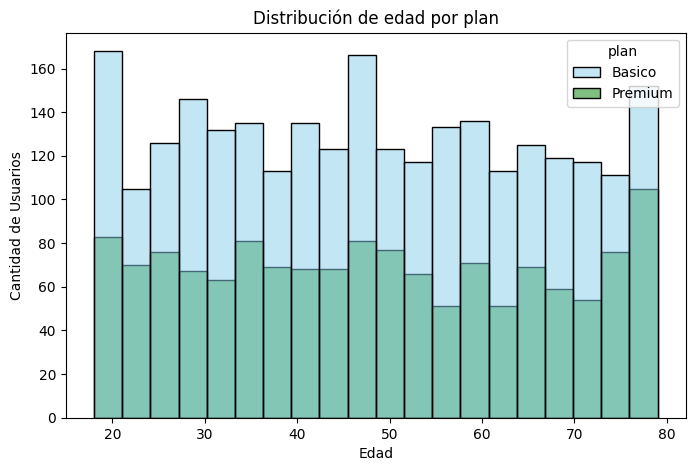

In [31]:
# Histograma para visualizar la edad (age)
plt.figure(figsize=(8,5))
sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue','green'],
    bins=20
)

plt.title('Distribución de edad por plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights: 
- Distribución

- No existe un patrón claro que indique que ciertas edades prefieren el plan Básico o Premium. La principal diferencia es que hay más usuarios en el plan Básico

- La distribución es aproximadamente uniforme, sin sesgo evidente hacia la derecha o hacia la izquierda y sin picos pronunciado. La distribución de edades es muy similar entre los planes Básico y Premium. Los usuarios de ambos planes se encuentran distribuidos a lo largo de todo el rango de edades (aproximadamente entre 18 y 79 años), sin que se observe una concentración clara en algún grupo etario específico.
El plan Básico presenta una mayor frecuencia de usuarios que el plan Premium, lo que sugiere que cuenta con una mayor cantidad de clientes en la muestra.
No se observa una relación evidente entre la edad y el tipo de plan contratado, ya que ambas distribuciones presentan una forma muy parecida.

Text(0, 0.5, 'Cantidad de Usuarios')

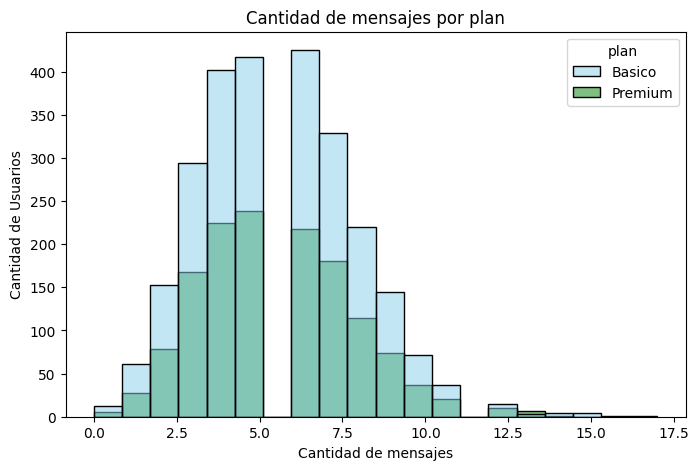

In [32]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(8,5))
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue','green'],
    bins=20
)

plt.title('Cantidad de mensajes por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de Usuarios')

💡Insights: 
- La distribución presenta un ligero sesgo hacia la derecha, ya que la mayor parte de los usuarios se concentra en valores bajos y medios, mientras que existe una cola con pocos usuarios que envían una cantidad elevada de mensajes.

-  Los usuarios de ambos planes presentan un comportamiento similar en cuanto al envío de mensajes, concentrándose principalmente entre 3 y 8 mensajes. El plan Básico muestra una mayor frecuencia de usuarios en casi todos los  rangos, lo cual es consistente con el hecho de que existen más clientes registrados en este plan. No se observa una diferencia significativa que indique que los usuarios Premium envían sustancialmente más mensajes que los usuarios Básico. También se identifican algunos usuarios con cantidades de mensajes considerablemente mayores al resto (por encima de 12 mensajes), lo que podría representar valores atípicos.

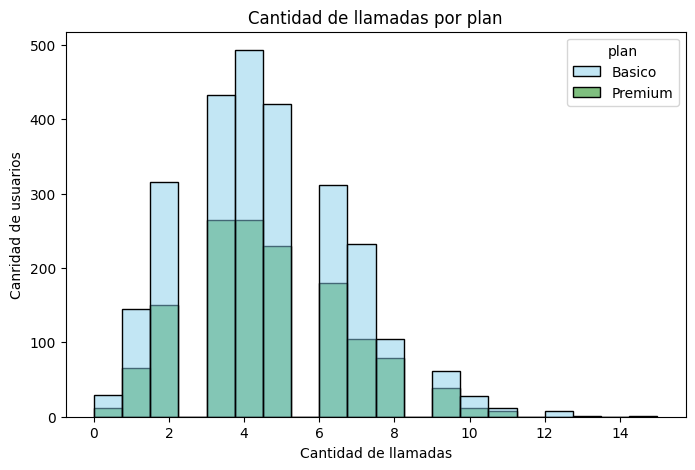

In [33]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(8,5))
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue','green'],
    bins=20
)

plt.title('Cantidad de llamadas por plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Canridad de usuarios')

plt.show()

💡Insights: 
Los usuarios de Básico son más numerosos (las barras azules son más altas).Tanto Básico como Premium tienen su pico alrededor de 4-5 llamadas. No se observa una diferencia drástica en el comportamiento de llamadas entre ambos planes. El plan Premium parece tener una presencia ligeramente mayor en valores altos de llamadas (7, 8, 9+), pero la diferencia no es muy marcada.

La cantidad de llamadas presenta una distribución sesgada a la derecha en ambos planes. La mayoría de los usuarios realiza entre 3 y 6 llamadas, mientras que pocos usuarios registran cantidades muy elevadas. No se observa un patrón claramente diferenciador entre los planes Básico y Premium, aunque los usuarios Premium parecen tener una ligera tendencia a concentrarse en cantidades más altas de llamadas.


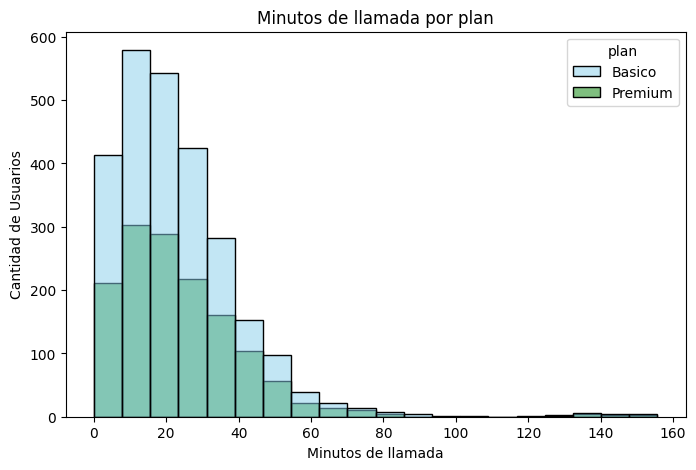

In [44]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(8,5))
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue','green'],
    bins=20
)

plt.title('Minutos de llamada por plan')
plt.xlabel('Minutos de llamada')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights: 
- La distribución presenta un sesgo a la derecha (asimetría positiva), ya que la mayoría de los usuarios se concentra entre 2 y 6 llamadas y existe una cola hacia valores altos (10, 12, 14 o más llamadas).
- Los usuarios de ambos planes presentan patrones de llamadas muy similares. La mayor concentración de usuarios se encuentra entre 3 y 6 llamadas, siendo 4 llamadas aproximadamente el valor más frecuente.

El plan Básico muestra una mayor frecuencia absoluta en todos los rangos, lo cual parece estar relacionado con que cuenta con más usuarios en la muestra. No se observa una diferencia clara que sugiera que los usuarios Premium realizan significativamente más llamadas que los usuarios Básico. Se identifican algunos usuarios con cantidades de llamadas superiores a 10, los cuales podrían considerarse posibles valores atípicos debido a su baja frecuencia.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

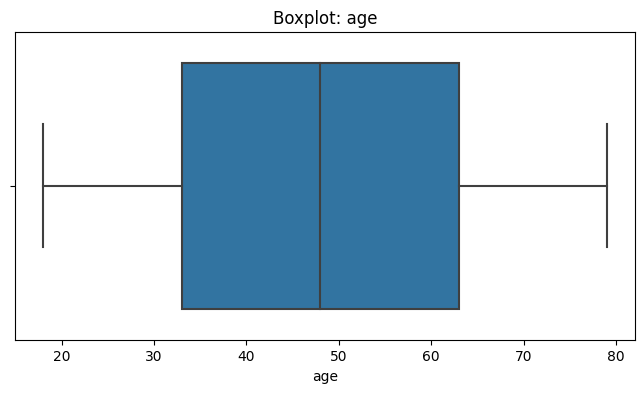

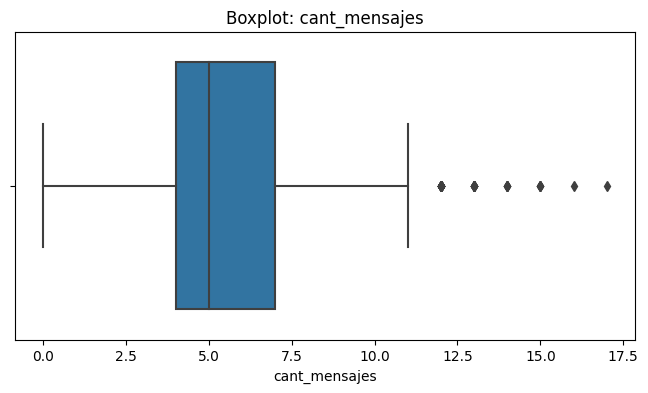

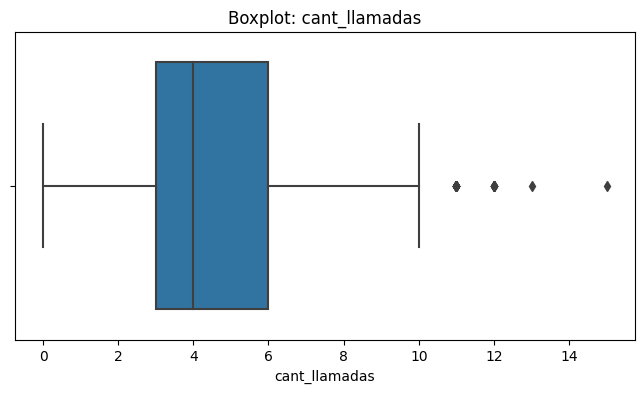

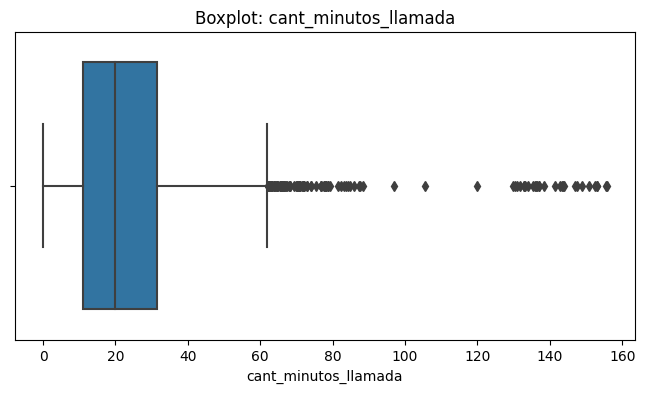

In [35]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.show()


💡Insights: 
1. age
No se observan puntos fuera de los bigotes del boxplot. No existen outliers aparentes en la edad. No es necesario calcular límites IQR para esta variable.
2. cant_mensajes
Se observan varios puntos por encima del bigote superior. Sí existen outliers superiores. No se observan outliers inferiores (además, los mensajes no pueden ser negativos). Conviene calcular únicamente el límite superior mediante IQR.
3. cant_llamadas
Se observan algunos puntos por encima del bigote superior. Sí existen outliers superiores. No se observan outliers inferiores. Conviene calcular únicamente el límite superior mediante IQR.
4. cant_minutos_llamada
Presenta una gran cantidad de valores extremos por encima del bigote superior. Sí existen outliers superiores significativos. No se observan outliers inferiores. Conviene calcular únicamente el límite superior mediante IQR.

Se identificaron outliers en las variables cant_mensajes, cant_llamadas y cant_minutos_llamada, principalmente del lado superior de la distribución. Sin embargo, estos valores representan usuarios con un uso más intensivo del servicio y no parecen ser errores de captura ni valores imposibles. Por lo tanto, se decidió conservar los outliers para no perder información relevante sobre el comportamiento real de los clientes.

In [36]:
# Calcular límites con el método IQR
columnas_limites = ['age','cant_mensajes','cant_llamadas','cant_minutos_llamada']

for col in columnas_limites:

    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)

    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR
    limite_inferior = Q1 - 1.5 * IQR

    print(f'{col}')
    print(f'Límite inferior: {limite_inferior:.2f}')
    print(f'Límite superior: {limite_superior:.2f}')

    outliers = user_profile[
        (user_profile[col] < limite_inferior) |
        (user_profile[col] > limite_superior)
    ]


age
Límite inferior: -12.00
Límite superior: 108.00
cant_mensajes
Límite inferior: -0.50
Límite superior: 11.50
cant_llamadas
Límite inferior: -1.50
Límite superior: 10.50
cant_minutos_llamada
Límite inferior: -19.32
Límite superior: 61.86


In [37]:

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights: 
La edad de los usuarios se distribuye de forma equilibrada entre los 18 y 79 años. La mediana de 48 años indica que la mitad de los clientes tiene menos de 48 años y la otra mitad más. No se identificaron valores atípicos según el método IQR, por lo que la variable presenta una distribución consistente y no requiere tratamiento adicional.

La mayoría de los usuarios envía entre 4 y 7 mensajes, con una mediana de 5 mensajes. Se detectaron algunos valores por encima del límite superior del método IQR, alcanzando un máximo de 17 mensajes. Estos valores representan usuarios más activos, pero no parecen corresponder a errores de captura, por lo que se decidió conservarlos para el análisis.

La mayoría de los usuarios realiza entre 3 y 6 llamadas. Se identificaron algunos valores atípicos por encima de 10.5 llamadas, alcanzando un máximo de 15 llamadas. Estos usuarios representan casos de uso intensivo del servicio, por lo que se decidió mantenerlos dentro del análisis.

El tiempo de llamadas presenta la mayor dispersión entre las variables analizadas. Aunque la mayoría de los usuarios consume menos de 32 minutos (percentil 75), existen usuarios que alcanzan hasta 155.69 minutos de conversación. Estos valores generan una marcada cola hacia la derecha y representan clientes con un uso significativamente más intensivo del servicio.

Se identificaron outliers en las variables cant_mensajes, cant_llamadas y especialmente cant_minutos_llamada. Sin embargo, los valores extremos son coherentes con el comportamiento esperado de algunos usuarios de alto consumo y no parecen ser errores de captura. Por ello, se decidió conservarlos para mantener la representatividad del análisis. La variable age no presenta outliers según el método IQR.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [38]:
# Crear columna grupo_uso
import numpy as np
user_profile['grupo_uso'] = np.where((user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    'Bajo uso',np.where((user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10),
        'Uso medio','Alto uso'))

In [39]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [40]:
# Crear columna grupo_edad
import numpy as np

user_profile['grupo_edad'] = np.where(
    user_profile['age'] < 30,'Joven',
    np.where(user_profile['age'] < 60,'Adulto','Adulto Mayor'))

In [41]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

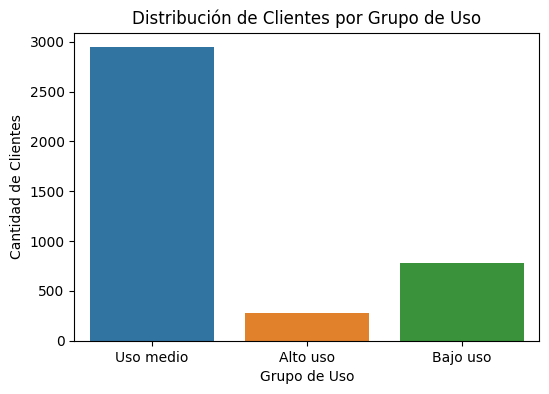

In [42]:
# Visualización de los segmentos por uso
plt.figure(figsize=(6,4))
sns.countplot(data=user_profile, x='grupo_uso')

plt.title('Distribución de Clientes por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Clientes')


plt.show()

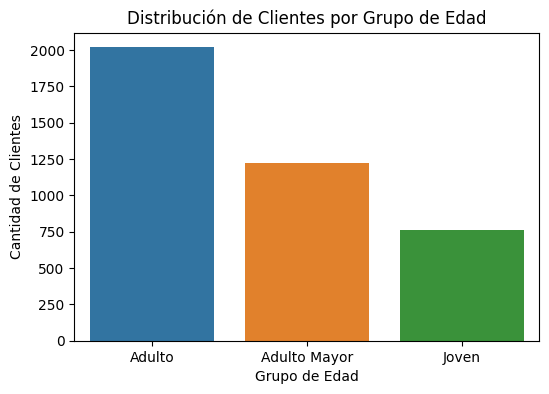

In [43]:
# Visualización de los segmentos por edad
plt.figure(figsize=(6,4))
sns.countplot(data=user_profile, x='grupo_edad')

plt.title('Distribución de Clientes por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Clientes')

plt.show()

# ---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
En la columna age se identificó el valor sentinel -999, que representaba una edad imposible. Este valor fue reemplazado por la mediana para evitar distorsionar el análisis.
En la columna city se encontró el valor "?", utilizado como marcador de información desconocida. Se reemplazó por valores nulos (pd.NA).
La columna city también contenía 469 valores nulos, equivalentes aproximadamente al 11.7% de los usuarios (469 de 4000 registros).
La columna churn_date presentaba 3534 valores nulos (88.4%), aunque estos no representan un problema de calidad, ya que indican usuarios que continúan activos.
En usage.date existían 50 registros sin fecha (0.13% del total).
Se detectaron 40 registros con fechas de registro en 2026, un año fuera del rango esperado del dataset (hasta 2024), por lo que fueron marcados como nulos.
Los nulos en duration y length resultaron ser estructurales: las llamadas tienen duración pero no longitud de mensaje, y los mensajes tienen longitud pero no duración. Por ello se conservaron como nulos.
Los outliers detectados en:

Cantidad de mensajes.
Cantidad de llamadas.
Minutos de llamada.

parecen concentrarse dentro del segmento de alto uso.

Esto implica que:

Existe una minoría de clientes con necesidades significativamente superiores al promedio.
Los planes actuales podrían no estar cubriendo de manera óptima sus patrones de consumo.
ConnectaTel tiene una oportunidad para diseñar productos premium que incrementen el ingreso promedio por usuario.

🔍 **Segmentos por Edad**

- Adultos: aproximadamente 2,020 clientes (≈50.5%). Constituyen el grupo más numeroso.Representan el mercado principal de ConnectaTel.
- Adultos mayores: aproximadamente 1,220 clientes (≈30.5%).Forman un segmento importante que podría requerir planes simples y fáciles de entender.
- Jóvenes: aproximadamente 760 clientes (≈19%).Son el grupo menos representado dentro de la cartera de clientes.

📊 **Segmentos por Nivel de Uso**
- Uso medio: aproximadamente 2,950 clientes (≈74% de la muestra). Es el segmento dominante. Representa usuarios con un patrón de consumo estable y predecible. Constituye la principal fuente de ingresos recurrentes.
- Bajo uso: aproximadamente 770 clientes (≈19% de la muestra). Utilizan el servicio ocasionalmente. Son más sensibles al precio y podrían beneficiarse de planes económicos.
- Alto uso: aproximadamente 280 clientes (≈7% de la muestra). Consumen significativamente más llamadas, mensajes o minutos que el promedio. Coinciden en gran medida con los outliers detectados. Son candidatos naturales para planes premium o especializados.




➡️ Esto sugiere que ...
El análisis muestra que ConnectaTel posee una base de clientes dominada por usuarios adultos de uso medio, que representan el núcleo del negocio. Sin embargo, existe un segmento pequeño pero estratégico de usuarios de alto consumo que genera oportunidades para planes premium y aumento de ingresos. La empresa puede mejorar su rentabilidad segmentando su oferta en función del nivel de uso y complementando dicha estrategia con propuestas adaptadas a cada grupo etario.

💡 **Recomendaciones**
Crear un plan de alto consumo
Dirigido a usuarios que superan frecuentemente el uso promedio.
Incluir mayores límites de llamadas y mensajes.
Mantener un plan económico para usuarios de bajo uso
Orientado a clientes que realizan pocas llamadas y envían pocos mensajes.
Permitiría reducir la probabilidad de cancelación por precio.
Desarrollar planes segmentados por comportamiento
Plan enfocado en llamadas.
Plan enfocado en mensajería.
Plan balanceado para usuarios promedio.
Monitorear a los usuarios intensivos
Identificar clientes con alto consumo.
Ofrecer beneficios exclusivos o programas de fidelización.
Utilizar analítica predictiva
Detectar usuarios que están aumentando su consumo.
Ofrecer actualizaciones de plan antes de que alcancen los límites contratados.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`